# **Analyzing Impact of Teacher Attributes on Student Evaluation**

## Probability Distribution


In this notebook, I used normal probability distributions to analyze the variables


### Objectives


*   Import Libraries
*   Normal Distributions


***


### Importing Libraries


Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from math import sqrt

Read in the csv file from the url using the request library


In [2]:
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv'
ratings_df = pd.read_csv(URL)

### Probability Distribution Analysis


### Normal Distribution


A normal distribution is a bell-shaped density curve described by its mean μ and standard deviation σ. The curve is symmetrical and centered around it's mean. A normal distribution curve looks like this:


![image.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/Templates/images/normalcurve.png)


Visualizing the curve. Importing norm from scipy.stat and ploting graph with matplotlib


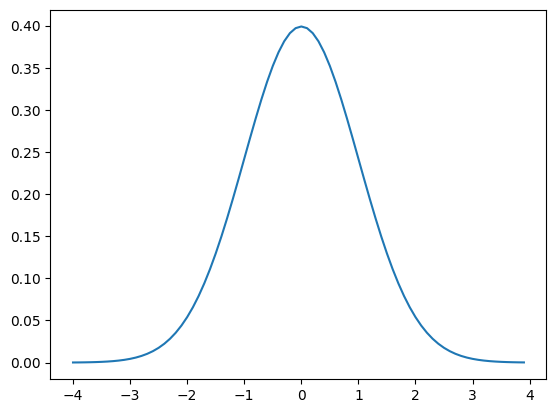

In [3]:
from scipy.stats import norm

# Plot between -4 and 4 with 0.1 steps.
x_axis = np.arange(-4, 4, 0.1)
# Mean = 0, SD = 1.
plt.plot(x_axis, norm.pdf(x_axis, 0, 1))
plt.show()

Calculating the probability of receiving an evaluation score of greater than 4.5


First, calculating the mean and standard deviation of teachers' evaluation scores


In [4]:
eval_mean = round(ratings_df['eval'].mean(), 3)
eval_sd = round(ratings_df['eval'].std(), 3)
print(eval_mean, eval_sd)

3.998 0.555


Using the scipy.stats module because python only looks to the left (less than). I subtracted the probability from 1 to get the other side of the tail because the area under the normal distribution is always 1.


In [6]:
prob0 = scipy.stats.norm.cdf((4.5 - eval_mean)/eval_sd)
print(round(1 - prob0, 3))

0.183


Calculating the probability of receiving an evaluation score greater than 3.5 and less than 4.2

First I found the probability of getting evaluation scores greater than 3.5 using the <code>norm.cdf</code> function


In [8]:
x1 = 3.5
prob1 = scipy.stats.norm.cdf((x1 - eval_mean)/eval_sd)
print(prob1)

0.1847801491443654


Then for less than 4.2


In [9]:
x2 = 4.2
prob2 = scipy.stats.norm.cdf((x2 - eval_mean)/eval_sd)
print(prob2)

0.642057540461896


The probability of a teacher receiving an evaluation score that is between 3.5 and 4.2 is:


In [12]:
round(prob2 - prob1, 3).item(0)

0.457

### Example:

Using the two-tailed test from a normal distribution:

*   A professional  basketball  team wants to compare its performance with  that of players  in a regional league.
*   The pros are known to have a historic mean of 12 points  per game with  a standard  deviation  of 5.5.
*   A group  of 36 regional players recorded on average 10.7 points  per game.
*   The pro coach would like to know whether  his professional  team scores on average are different from that of the regional players.


Stating the null hypothesis

*   $H\_0$:  $x = µ\_1$  ( The mean point of the regional players is not different from the historic mean )
*   $H\_1$:  $x ≠ µ\_1$  ( The mean point of the regional players is different from the historic mean )


When the population standard deviation is given and dealing with a sub-sample, the size (n) of the sub-sample is used in the formula:

![image.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/gONGgeGRqjR7SNUtkRwssQ/image.png)


In [14]:
## because it is a two-tailed test I multiplied it by 2
2*round(scipy.stats.norm.cdf((10.7 - 12)/(5.5/sqrt(36))), 3).item(0)

0.156

**Conclusion:** Because the p-value is greater than 0.05, we fail to reject the null hypothesis as there is no sufficient evidence to prove that the mean point of the regional players is different from the historic mean


Calculating the probability of receiving an evaluation score greater than 3.3


In [17]:
prob_less_than = scipy.stats.norm.cdf((3.3 - eval_mean)/eval_sd)
#Removjng the probability from 1 to get the area to the right of 3.3
round(1 - prob_less_than, 3).item(0)

0.896

Calculating the probability of receiving an evaluation score between 2 and 3


In [19]:
# Calculating the probablity of reciving a score of less than 2
prob_less_than_2 = scipy.stats.norm.cdf((x1 - eval_mean)/eval_sd)
print(prob_less_than_2)

# Calculating the probablity of reciving a score of less than 3
prob_less_than_3 = scipy.stats.norm.cdf((x2 - eval_mean)/eval_sd)
print(prob_less_than_3)

# Subtracting both probabilities from each other
round((prob_less_than_3 - prob_less_than_2)*100, 1).item(0)

0.1847801491443654
0.642057540461896


45.7

Testing the hypothesis that sleeping for at least 8 hours makes one smarter, 12 people who have slept for at least 8 hours every day  for the past one year  have their IQ tested.

*   Results: 116, 111, 101, 120, 99, 94, 106, 115, 107, 101, 110, 92
*   Hypotheses: H0: μ = 100 or Ha: μ > 100


In [24]:
iqs = [116, 111, 101, 120, 99, 94, 106, 115, 107, 101, 110, 92]
sample_size = len(iqs)
degree_freedom = sample_size - 1

iq_mean = sum(iqs) / sample_size
mean_diff = [(iq - iq_mean) ** 2 for iq in iqs]
iq_std = sqrt(sum(mean_diff) / degree_freedom)
variance = iq_std ** 2

print(f"IQ mean is {round(iq_mean, 3)}, sd is {round(iq_std, 3)}, variance is {round(variance, 3)}")
round(1-scipy.stats.norm.cdf((iq_mean - 100)/(iq_std/sqrt(12))), 3).item(0)

IQ mean is 106.0, sd is 8.832, variance is 78.0


0.009

---

## Author

- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)
